# Run the complete election pipeline
Evaluate eight candidates across five outer elections, select by equal-weight mean accuracy, then retune, refit and evaluate 2024. Configure PostgreSQL and the tracking server first using docs/postgresql.md and docs/mlflow.md. The pipeline automatically reads .env.election. Source .mlflow/config.env before starting Jupyter for tracking settings. Rerun the setup cell below after updating the database code, including in an existing kernel.

Prepared CSVs, predictor guide, final predictions and confusion matrices remain in notebooks/outputs. Compact experiment histories are retained in MLflow.


In [5]:
import os
import importlib

# Use the local tracking server unless a server is already configured.
os.environ.setdefault("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")

from election import paths
from election.sql import apply_sql_queries

# Refresh database setup when this cell is rerun in an existing kernel.
importlib.reload(apply_sql_queries)
from election.pipeline.run_pipeline import run_pipeline

project_root = paths.project_root()

output_directory = project_root / "notebooks" / "outputs"
print(f"Saving pipeline outputs to: {output_directory}")


Saving pipeline outputs to: /workspaces/Election-Prediction-12.08/notebooks/outputs


In [6]:
selection = run_pipeline(output_dir=output_directory)
final_model = selection.model
report = selection.report
model_type = selection.model_name
import pandas as pd
display(report.scorecard())
display(pd.DataFrame(report.outer_results))
print(f"Selected model: {model_type}; status: {report.status}; execution: {report.execution_id}")
print("Final selected configuration:", report.final_fit)


/workspaces/Election-Prediction-12.08/.venv/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Outer election 2005: tuning and fitting XGBoost
🏃 View run XGBoost: 2005 at: http://127.0.0.1:5000/#/experiments/67/runs/c3e53493763f45469791c3ab5f0108ee
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
Completed XGBoost: 2005
Outer election 2005: tuning and fitting Random Forest
🏃 View run Random Forest: 2005 at: http://127.0.0.1:5000/#/experiments/67/runs/0d15029cfccc432390ce60248321c57b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
Completed Random Forest: 2005
Outer election 2005: tuning and fitting Logistic Regression
🏃 View run Logistic Regression: 2005 at: http://127.0.0.1:5000/#/experiments/67/runs/9615941e85ec48ff9679c1ed3ee63170
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/67
Completed Logistic Regression: 2005
Outer election 2005: tuning and fitting NN01: 32/16 validation-selected rate
  NN01: 32/16 validation-selected rate: 2/4 configurations scored
🏃 View run NN01: 32/16 validation-selected rate: 2005 at: http://127.0.0.1:5000/#/expe

,candidate,mean_accuracy,mean_changed_seat_accuracy,mean_retained_seat_accuracy,mean_macro_f1,mean_log_loss,accuracy_elections,changed_seat_accuracy_elections,retained_seat_accuracy_elections,macro_f1_elections,log_loss_elections
0,Conditional XGBoost,0.888176,0.196466,0.986689,0.730481,0.348024,5,5,5,5,5
1,XGBoost Expanded,0.877114,0.334511,0.958812,0.600526,0.415624,5,5,5,5,5
2,XGBoost,0.875210,0.310386,0.959987,0.630834,0.379061,5,5,5,5,5
3,Random Forest,0.871719,0.191097,0.972109,0.615020,0.460507,5,5,5,5,5
4,NN03: 16 units fixed rate 0.3,0.861590,0.305646,0.941728,0.600979,0.466410,5,5,5,5,5
5,NN01: 32/16 validation-selected rate,0.861286,0.291343,0.944322,0.599943,0.465544,5,5,5,5,5
6,Logistic Regression,0.860016,0.264261,0.945395,0.631110,0.477598,5,5,5,5,5
7,NN02: 64/32 validation-selected rate,0.857468,0.339615,0.933904,0.583671,0.477315,5,5,5,5,5


,candidate,election,accuracy,changed_seat_accuracy,retained_seat_accuracy,macro_f1,log_loss,evaluation_rows,changed_seat_evaluation_rows,retained_seat_evaluation_rows,previous_winner_known_rows
0,XGBoost,2019,0.919304,0.513158,0.974820,0.785602,0.198215,632,76,556,632
1,XGBoost,2017,0.868671,0.119403,0.957522,0.504480,0.336220,632,67,565,632
2,XGBoost,2015,0.810127,0.165138,0.944551,0.540622,0.739788,632,109,523,632
3,XGBoost,2010,0.862342,0.491071,0.942308,0.671896,0.346051,632,112,520,632
4,XGBoost,2005,0.915605,0.263158,0.980736,0.651570,0.275029,628,57,571,628
5,Random Forest,2019,0.903481,0.315789,0.983813,0.673465,0.256541,632,76,556,632
6,Random Forest,2017,0.893987,0.074627,0.991150,0.582046,0.306287,632,67,565,632
7,Random Forest,2015,0.783228,0.119266,0.921606,0.443659,1.025853,632,109,523,632
8,Random Forest,2010,0.870253,0.410714,0.969231,0.691529,0.378509,632,112,520,632
9,Random Forest,2005,0.907643,0.035088,0.994746,0.684402,0.335346,628,57,571,628


Selected model: Conditional XGBoost; status: complete; execution: 229c5ca9ad2f4bc9b3c7e876815350ab
Final selected configuration: {'candidate': 'Conditional XGBoost', 'forecast_election': 2024, 'configuration': {'change.n_estimators': 50, 'change.max_depth': 2, 'change.learning_rate': 0.05, 'change.min_child_weight': 1, 'change.gamma': 0, 'change.subsample': 1, 'change.colsample_bytree': 1, 'change.reg_alpha': 0, 'change.reg_lambda': 1, 'change.tree_method': 'hist', 'change.random_state': 42, 'change.n_jobs': 1, 'challenger.n_estimators': 200, 'challenger.max_depth': 2, 'challenger.learning_rate': 0.05, 'challenger.min_child_weight': 1, 'challenger.gamma': 0, 'challenger.subsample': 1, 'challenger.colsample_bytree': 1, 'challenger.reg_alpha': 0, 'challenger.reg_lambda': 1, 'challenger.tree_method': 'hist', 'challenger.random_state': 42, 'challenger.n_jobs': 1}, 'training_years': (1987, 1992, 1997, 2001, 2005, 2010, 2015, 2017, 2019), 'refit_durations': {}}


## Final 2024 results
The pipeline has already evaluated and logged the final model. These cells display returned results and the saved confusion matrix.


accuracy                           0.737342
evaluation_rows                  632.000000
changed_seat_accuracy              0.470000
changed_seat_evaluation_rows     300.000000
retained_seat_accuracy             0.981873
retained_seat_evaluation_rows    331.000000
macro_f1                           0.485283
log_loss                           0.637364
previous_winner_accuracy           0.523734
previous_winner_known_rows       631.000000
seat_error_con                   102.000000
seat_error_lab                   -86.000000
seat_error_lib                   -38.000000
seat_error_natSW                  37.000000
seat_error_oth                   -15.000000
test_rows                        632.000000
excluded_rows                      0.000000
Name: 2024, dtype: float64

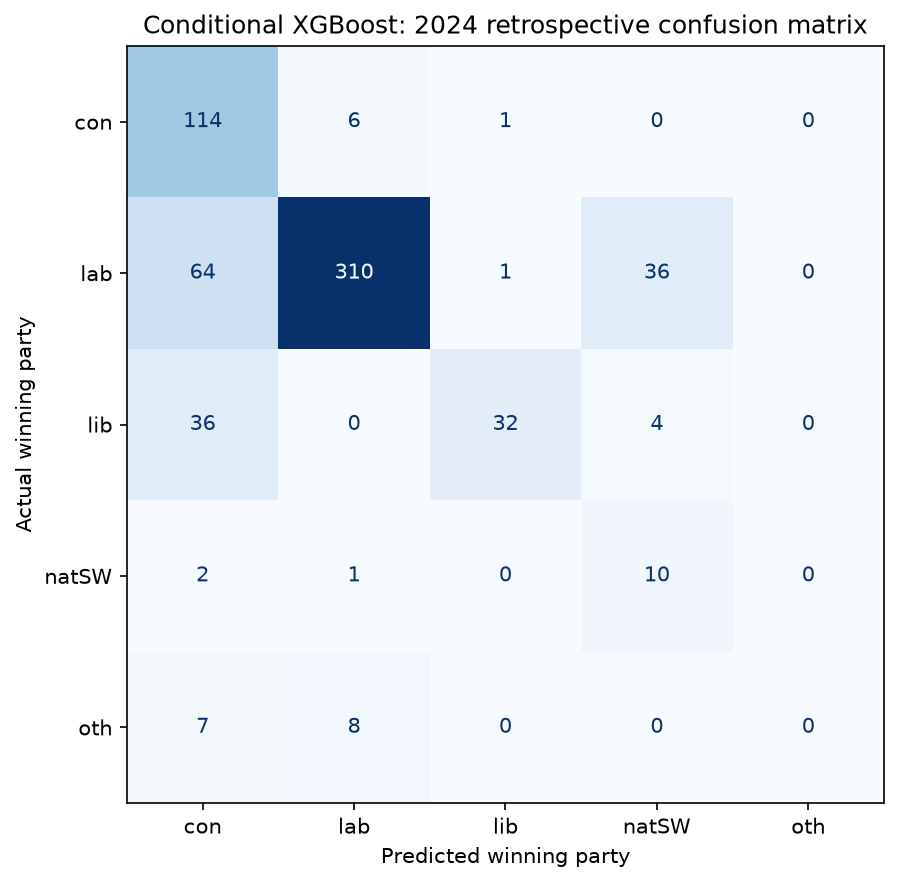

In [7]:
display(pd.Series(report.final_metrics, name="2024"))
from IPython.display import Image, display
display(Image(filename=str(output_directory / "test_confusion_matrix.png")))
